In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
df = pd.read_excel('C:/Users/fabia/PycharmProjects/Minería de Datos/Dataset impacto OEE.xlsx', sheet_name='Eventos de perdida')

In [4]:
df.columns

Index(['Loss event ID', 'Process', 'Machine', 'Date', 'Shift', 'Part code',
       'duration (minutes)', 'OEE LOSS TYPE', 'Impacto por minuto',
       '$ LOSS (Impacto en KPI Financiero)  por tiempo perdido', 'SCRAP parts',
       'REWORK parts'],
      dtype='object')

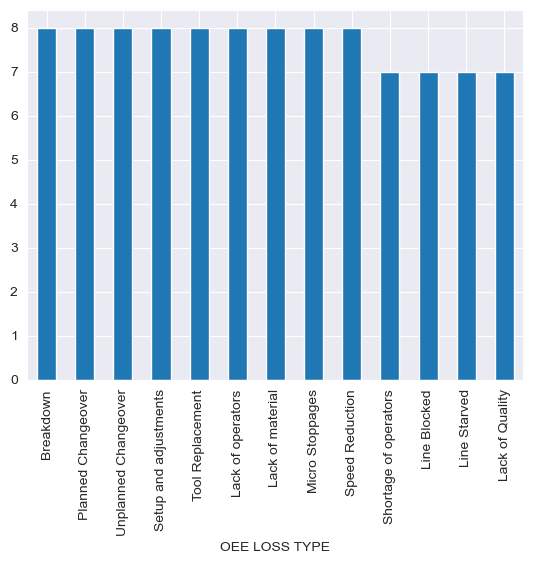

In [5]:
df['OEE LOSS TYPE'].value_counts().plot(kind = 'bar');

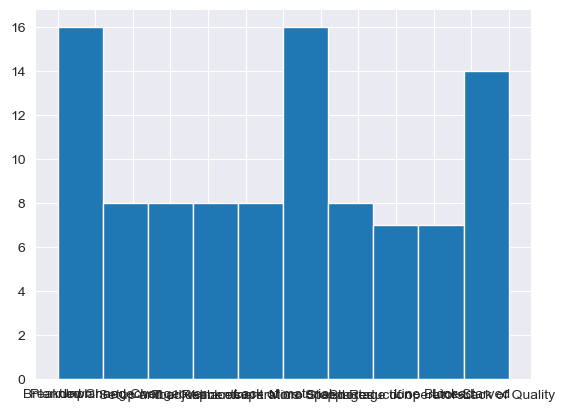

In [6]:
df['OEE LOSS TYPE'].hist();

In [7]:
# Crear tabla pivote
tabla = df.pivot_table(index='OEE LOSS TYPE', columns='Process', values='$ LOSS (Impacto en KPI Financiero)  por tiempo perdido', aggfunc='sum')
tabla

Process,Process A,Process B,Process C
OEE LOSS TYPE,,,
Breakdown,2975.0,2892.982456,2414.772727
Lack of Quality,120.0,690.058480,87.500000
Lack of material,3960.0,711.111111,2711.818182
Lack of operators,3725.0,205.263158,175.000000
Line Blocked,565.0,157.894737,295.909091
Line Starved,1025.0,NaN,207.272727
Micro Stoppages,125.0,1057.894737,NaN
Planned Changeover,4500.0,789.473684,259.090909
Setup and adjustments,1885.0,755.555556,1995.000000


In [8]:
tabla[tabla.isna().any(axis=1)]

Process,Process A,Process B,Process C
OEE LOSS TYPE,,,
Line Starved,1025.0,NaN,207.272727
Micro Stoppages,125.0,1057.894737,NaN
Shortage of operators,NaN,311.111111,573.181818


In [9]:
tabla['Process A'] = tabla['Process A'].fillna(tabla['Process A'].mean())
tabla['Process B'] = tabla['Process B'].fillna(tabla['Process B'].mean())
tabla['Process C'] = tabla['Process C'].fillna(tabla['Process C'].mean())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                                                  Non-Null Count  Dtype         
---  ------                                                  --------------  -----         
 0   Loss event ID                                           100 non-null    int64         
 1   Process                                                 100 non-null    object        
 2   Machine                                                 100 non-null    object        
 3   Date                                                    100 non-null    datetime64[ns]
 4   Shift                                                   100 non-null    object        
 5   Part code                                               100 non-null    object        
 6   duration (minutes)                                      100 non-null    int64         
 7   OEE LOSS TYPE                                           100 non

In [10]:
tabla

Process,Process A,Process B,Process C
OEE LOSS TYPE,,,
Breakdown,2975.00,2892.982456,2414.772727
Lack of Quality,120.00,690.058480,87.500000
Lack of material,3960.00,711.111111,2711.818182
Lack of operators,3725.00,205.263158,175.000000
Line Blocked,565.00,157.894737,295.909091
Line Starved,1025.00,903.557505,207.272727
Micro Stoppages,125.00,1057.894737,1053.238636
Planned Changeover,4500.00,789.473684,259.090909
Setup and adjustments,1885.00,755.555556,1995.000000


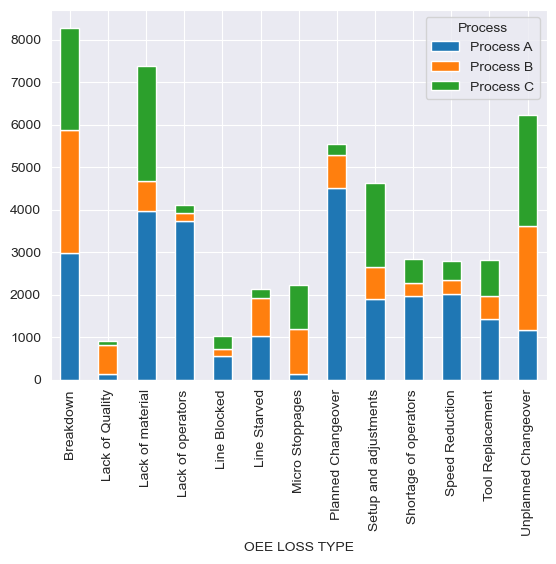

In [11]:
tabla.plot(kind = 'bar', stacked = True);

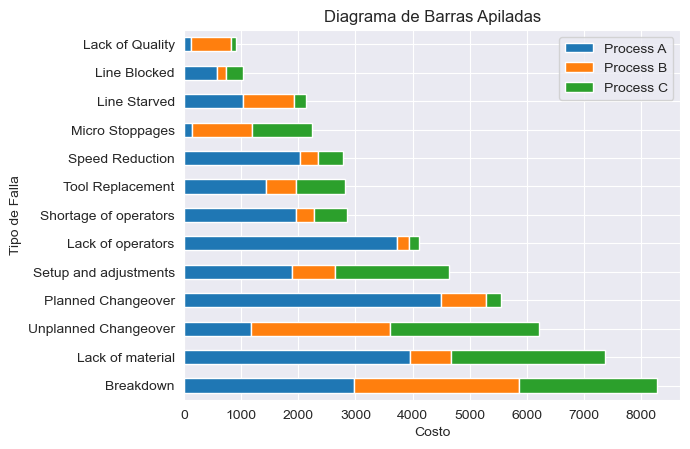

In [18]:
import matplotlib.pyplot as plt

# Crear el DataFrame con los datos
data = {
    "Process": [
        "Breakdown", "Lack of Quality", "Lack of material", "Lack of operators",
        "Line Blocked", "Line Starved", "Micro Stoppages", "Planned Changeover",
        "Setup and adjustments", "Shortage of operators", "Speed Reduction",
        "Tool Replacement", "Unplanned Changeover"
    ],
    "Process A": [
        2975.00, 120.00, 3960.00, 3725.00, 565.00, 1025.00, 125.00, 4500.00, 
        1885.00, 1958.75, 2025.00, 1430.00, 1170.00
    ],
    "Process B": [
        2892.98, 690.06, 711.11, 205.26, 157.89, 903.56, 1057.89, 789.47, 
        755.56, 311.11, 311.11, 525.73, 2434.50
    ],
    "Process C": [
        2414.77, 87.50, 2711.82, 175.00, 295.99, 207.27, 1053.24, 259.09, 
        1995.00, 573.18, 451.59, 854.09, 2613.64
    ]
}

df = pd.DataFrame(data)

# Ordenar el DataFrame por la suma de las columnas (mayor a menor)
df['Total'] = df[['Process A', 'Process B', 'Process C']].sum(axis=1)
df = df.sort_values('Total', ascending=False)

# Graficar
df.set_index('Process')[['Process A', 'Process B', 'Process C']].plot(kind='barh', stacked=True)

plt.title('Diagrama de Barras Apiladas')
plt.xlabel('Costo')
plt.ylabel('Tipo de Falla')
plt.show()

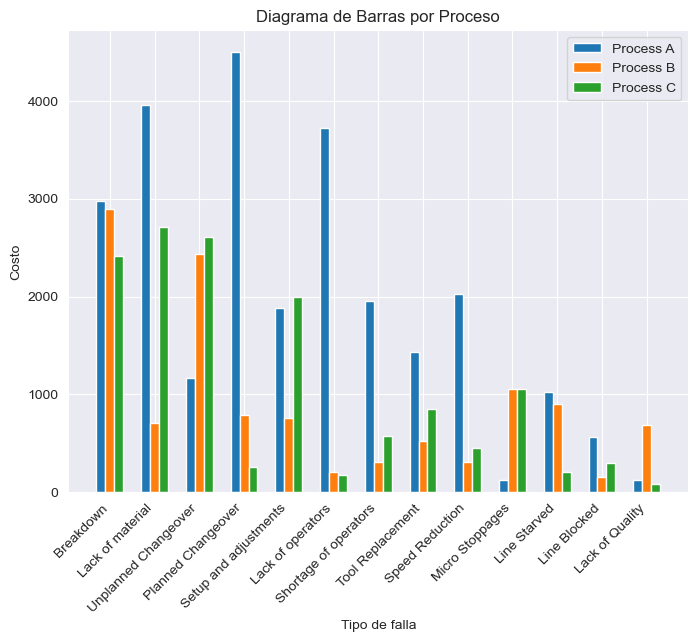

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

# Definir el ancho de las barras y la posición en el eje x
bar_width = 0.2
x = np.arange(len(df['Process']))

# Crear las barras
ax.bar(x - bar_width, df['Process A'], width=bar_width, label='Process A')
ax.bar(x, df['Process B'], width=bar_width, label='Process B')
ax.bar(x + bar_width, df['Process C'], width=bar_width, label='Process C')

# Añadir etiquetas y título
ax.set_xlabel('Tipo de falla')
ax.set_ylabel('Costo')
ax.set_title('Diagrama de Barras por Proceso')
ax.set_xticks(x)
ax.set_xticklabels(df['Process'], rotation=45, ha='right')
ax.legend()

In [21]:
#df['Process A'].value_counts().plot(kind = 'bar', width = 0.50, alpha = 1, color = ['y', 'r', 'b']);

KeyError: 'OEE LOSS TYPE'

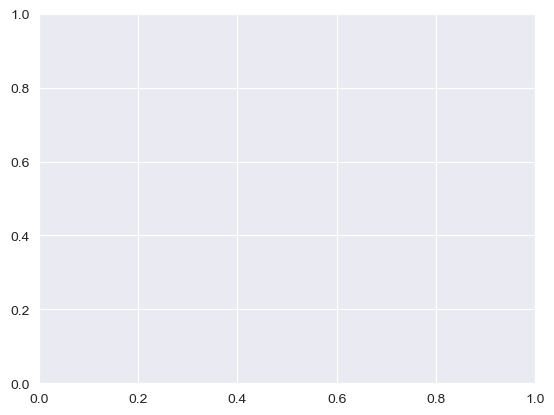

In [14]:
fig, ax = plt.subplots()
h=ax.hist(df['OEE LOSS TYPE'], bins=10, color='skyblue', edgecolor='black', cumulative=False)
h[2][4].set_facecolor('orange')
df = df.sort_values(by='$ LOSS (Impacto en KPI Financiero)  por tiempo perdido', ascending=False)
ax.set_title('Fallas más recurrentes')
plt.show();

In [ ]:
fig, ax = plt.subplots()
ax.boxplot(df['duration (minutes)'])
ax.set_title('Duracion de la falla');

In [ ]:
df['OEE LOSS TYPE'].mode()

In [ ]:
df2_column= df[['$ LOSS (Impacto en KPI Financiero)  por tiempo perdido', 'duration (minutes)', 'Part code']]
df2_column

In [ ]:
df2_column.head()

In [ ]:
df2_column.info()

In [ ]:
df.info()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
#import pandas as pd
 
# Cargar los datos
#data = pd.read_csv("data.csv")
 
# Convertir la columna de fechas a formato datetime y date2num
df["Date"] = pd.to_datetime(df["Date"]).apply(mdates.date2num)
 
# Crear el gráfico
fig, ax = plt.subplots()
 
# Configurar el localizador de ticks
ax.xaxis.set_major_locator(mdates.MonthLocator())
 
# Configurar el formateador de ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
 
# Graficar los datos
ax.plot_date(df["Date"], df["OEE LOSS TYPE"], linestyle="solid")
 
# Mostrar el gráfico
plt.show()